In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
import os

In [2]:
load_dotenv(override=True)

True

In [3]:
model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

In [12]:
items = {
    "facewash": {
        "cost": 500,
        "discount_percent": 50,
        "delivery_charge": 50
    },
    "moisturizer": {
        "cost": 400,
        "discount_percent": 50,
        "delivery_charge": 50
    },
    "sunscreen": {
        "cost": 900,
        "discount_percent": 20,
        "delivery_charge": 30
    }
}

In [13]:
items

{'facewash': {'cost': 500, 'discount_percent': 50, 'delivery_charge': 50},
 'moisturizer': {'cost': 400, 'discount_percent': 50, 'delivery_charge': 50},
 'sunscreen': {'cost': 900, 'discount_percent': 20, 'delivery_charge': 30}}

Start -> Summary, keywords, sentiments -> final_merge_response -> End

In [29]:
class ParallelState(TypedDict):
    text: str
    summary: str
    keywords: str
    sentiment: str
    final: str

In [30]:
graph = StateGraph(ParallelState)

In [31]:
def summarize(state: ParallelState):
    text = state['text']
    prompt = f'Summarize the given text {text} into 50-100 words'
    summary = model.invoke(prompt).content
    return {'summary': summary}

In [32]:
def keyword_extraction(state: ParallelState):
    text = state['text']
    prompt = f'Extract the important keywords from the given text {text}'
    keywords = model.invoke(prompt).content
    return {'keywords': keywords}

In [33]:
def sentiment_analysis(state: ParallelState):
    text = state['text']
    prompt = f'Analyse the sentiment of the text {text}, is this Positive/Negative/Neutral '
    sentiment = model.invoke(prompt).content
    return {'sentiment': sentiment}

In [34]:
def merge(state: ParallelState):
    text = state['text']
    summary = state['summary']
    keywords = state['keywords']
    sentiment = state['sentiment']
    prompt = f""" You are an helpful assistant, considering {text}, {summary}, {keywords} and {sentiment}. Give a final user-friendly insight in 2-3 lines.
    """
    final = model.invoke(prompt).content
    return {'final': final}

In [35]:
graph.add_node("summarize", summarize)
graph.add_node("keyword_extraction", keyword_extraction)
graph.add_node("sentiment_analysis", sentiment_analysis)
graph.add_node("merge", merge)

In [36]:
graph.add_edge(START, "summarize")
graph.add_edge(START, "keyword_extraction")
graph.add_edge(START, "sentiment_analysis")

graph.add_edge("summarize", "merge")
graph.add_edge("keyword_extraction", "merge")
graph.add_edge("sentiment_analysis", "merge")

graph.add_edge( "merge", END)

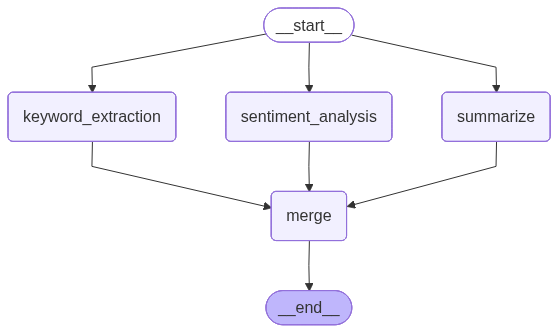

In [37]:
graph.compile()

In [39]:
workflow = graph.compile()
final_state = workflow.invoke({"text":"""
The cart contains three skincare items:
1. Facewash costs 500 with a 50% discount and 50 delivery charge.
2. Moisturizer costs 400 with a 50% discount and 50 delivery charge.
3. Sunscreen costs 900 with a 20% discount and 30 delivery charge.
"""})

In [40]:
final_state

{'text': '\nThe cart contains three skincare items:\n1. Facewash costs 500 with a 50% discount and 50 delivery charge.\n2. Moisturizer costs 400 with a 50% discount and 50 delivery charge.\n3. Sunscreen costs 900 with a 20% discount and 30 delivery charge.\n',
 'summary': 'The cart contains three skincare items: Facewash (500, 50% discount, 50 delivery), Moisturizer (400, 50% discount, 50 delivery), and Sunscreen (900, 20% discount, 30 delivery). The discounts and delivery charges apply to each item. The total cost will be calculated after applying the discounts and adding the delivery charges for each item.',
 'keywords': 'The important keywords extracted from the text are:\n\n1. Skincare\n2. Facewash\n3. Moisturizer\n4. Sunscreen\n5. Discount\n6. Delivery charge\n7. Prices (500, 400, 900)\n8. Discount percentages (50%, 20%)',
 'sentiment': 'The sentiment of the text is Neutral. \n\nThe text is providing factual information about the items in the cart, their costs, discounts, and deli